In [ ]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import numpy as np
from scipy.interpolate import PchipInterpolator

def interpolador(subject, method, size):
    # data = np.array([int(line.strip()) for line in subject.to_numpy()])  # Si lo obtienes de un DataFrame
    data = subject
    x = np.arange(len(data))
    
    # Crear 'size' puntos equidistantes
    x_new = np.linspace(0, len(data) - 1, size*(len(data)-1) + len(data))
    
    if method == 'lineal':
        data_interp = np.interp(x_new, x, data)
    elif method == 'herm':
        interpolator = PchipInterpolator(x, data)
        data_interp = interpolator(x_new)
    
    return x_new, data_interp

def interpolador_constante(subject):
    # data = np.array([int(line.strip()) for line in subject.to_numpy()])  # Si lo obtienes de un DataFrame
    x = np.arange(2)
    data_interp = np.array([])
    diferencias =np.abs(np.diff(subject))
    if (np.max(diferencias) - np.min(diferencias)) <= 1e-5:
        return subject
    diferencias_sin_0 = diferencias[diferencias != 0]
    diferencias = np.round(diferencias/np.min(diferencias_sin_0))
    for i in range(len(subject)-1):
        data = subject[i:i+2]
        if diferencias[i] == 0:
            data_interp = np.concatenate((data_interp,data[:-1]))
            continue
        size = int(diferencias[i])- 1
        # Crear 'size' puntos equidistantes
        x_new = np.linspace(0, 1, size + 2)
        interp_step = np.interp(x_new, x, data)
        data_interp = np.concatenate((data_interp,interp_step[:-1]))
    data_interp = np.concatenate((data_interp,np.array([data[-1]])))

    return data_interp

def J_univariante(X, tau=1):
    X = np.array(X)
    x1 = X[tau:]
    y1 = X[:-tau]
    ff1 = np.angle(np.fft.rfft(x1))
    ff2 = np.angle(np.fft.rfft(y1))
    vectores = []
    for i in range(len(ff1) - 1):
        p1 = [ff1[i], ff2[i]]
        p2 = [ff1[i + 1], ff2[i + 1]]
        cuadrante = [
            [p2[0] - p1[0], p2[1] - p1[1]],
            [p2[0] - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
        ]
        distancias = np.array([np.linalg.norm(np.array(c) - np.array(p1)) for c in cuadrante])
        p2 = cuadrante[np.argmin(distancias)]
        vectores.append([p2[0] - p1[0], p2[1] - p1[1]])

    vectores = np.array(vectores)
    norms = np.linalg.norm(vectores, axis=1, keepdims=True)
    v_norm = np.where(norms == 0, vectores, vectores / norms)
    
    angulos = np.arccos(np.clip(np.einsum('ij,ij->i', v_norm[:-1], v_norm[1:]), -1.0, 1.0))
    cruces = np.cross(v_norm[:-1], v_norm[1:])
    angulos = np.where(cruces > 0, np.pi - angulos, angulos)
    angulos = np.where((cruces == 0) & (angulos < 0), np.pi, angulos)
    angulos = np.where(cruces < 0, angulos + np.pi, angulos)

    e = np.exp(angulos * 1j)
    e1 = np.sum(e) / len(angulos)
    J = 1.0 - np.abs(e1.real)
    
    return J

def J_bivariante(X, Y):
    X = np.array(X)
    x1 = X
    y1 = Y
    ff1 = np.angle(np.fft.rfft(x1))
    ff2 = np.angle(np.fft.rfft(y1))

    vectores = []
    for i in range(len(ff1) - 1):
        p1 = [ff1[i], ff2[i]]
        p2 = [ff1[i + 1], ff2[i + 1]]
        cuadrante = [
            [p2[0] - p1[0], p2[1] - p1[1]],
            [p2[0] - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] + 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - 2 * np.pi - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] - p1[1]],
            [p2[0] - 2 * np.pi - p1[0], p2[1] + 2 * np.pi - p1[1]],
        ]
        distancias = np.array([np.linalg.norm(np.array(c) - np.array(p1)) for c in cuadrante])
        p2 = cuadrante[np.argmin(distancias)]
        vectores.append([p2[0] - p1[0], p2[1] - p1[1]])

    vectores = np.array(vectores)
    norms = np.linalg.norm(vectores, axis=1, keepdims=True)
    v_norm = np.where(norms == 0, vectores, vectores / norms)
    
    angulos = np.arccos(np.clip(np.einsum('ij,ij->i', v_norm[:-1], v_norm[1:]), -1.0, 1.0))
    cruces = np.cross(v_norm[:-1], v_norm[1:])
    angulos = np.where(cruces > 0, np.pi - angulos, angulos)
    angulos = np.where((cruces == 0) & (angulos < 0), np.pi, angulos)
    angulos = np.where(cruces < 0, angulos + np.pi, angulos)

    e = np.exp(angulos * 1j)
    e1 = np.sum(e) / len(angulos)
    J = 1.0 - np.abs(e1.real)
    
    return J

def generar_uniforme_centrada(n, varianza):
    # Calcular el límite superior e inferior de la distribución uniforme
    limite = np.sqrt(varianza) # varianza*3
    # Generar n números aleatorios con distribución uniforme entre -limite y limite
    return np.random.uniform(-limite, limite, n)

def brownian_bridge(t0, tT, x0, xT, n_steps):
    t = np.linspace(t0, tT, n_steps)
    #Generar movimiento browniano con media cero
    W = np.random.normal(0, np.sqrt(t[1] - t[0]), size=n_steps-1)
    W = np.insert(np.cumsum(W), 0, 0)  # Inserta W(0) = 0 y suma acumulativa
    # Interpolación del Brownian Bridge
    X = x0 + (t - t0) / (tT - t0) * (xT - x0) + W - (t - t0) / (tT - t0) * W[-1]
    return t, X

def interpolador_estocastico(s_0_discreto, n_steps):
    t_list, X_list = [], []
    for i in range(len(s_0_discreto)- 1):
        t0 = i
        tT = i+1
        x0 = s_0_discreto[i]
        xT = s_0_discreto[i+1]
        t, X = brownian_bridge(t0, tT, x0, xT, n_steps)
        t_list = np.concatenate((t_list, t))
        X_list = np.concatenate((X_list, X))
    return X_list

def remove_consecutive_duplicates(data, tolerance=1e-1):
    """
    Remueve duplicados consecutivos en los datos con un margen de tolerancia.

    Args:
        data (list or array): Array de datos a procesar.
        tolerance (float): Margen de tolerancia para considerar valores similares.

    Returns:
        list: Array con duplicados consecutivos removidos.
    """
    if not data:
        return []

    result = [data[0]]  # Comenzamos con el primer elemento
    for i in range(1, len(data)):
        if abs(data[i] - data[i - 1]) > tolerance:
            result.append(data[i])

    return np.array(result)

def derivada_index(array):
    array = np.asarray(array)
    derivada = np.abs(np.diff(array))  # Calcula la diferencia entre puntos subsecuentes
    return derivada


In [60]:

# N0 = np.arange(10,20,1)
# N1 = np.arange(20,100,5)
# N2 = np.arange(100,2000,10)
# N3 = np.arange(2000,10000,100)
# N4 = np.arange(10000,100000,500)
# N5 = np.arange(100000,500000,1000)
# N6 = np.arange(500000,1000000,2000)
# N7 = np.arange(1000000,2500000,10000)
# Ns = np.concatenate((N0,N1,N2,N3,N4,N5,N6,N7))
# J_min = []

# for N in Ns:
#     subjects = [J_null(N) for _ in range(100)]
#     J_N = np.mean(np.array([np.min(np.array(subjects)) for _ in range(100)]))
#     J_min.append(J_N)


# derivadas = derivada_index(Ns)

# Js_interp = np.array([J_min[0]])
# for i,der in enumerate(derivadas):
#     Js_interp = np.concatenate((Js_interp, interpolador(J_min[i:i+2],'lineal',der-1)[1][1:]))

        
# print(len(interpolador_constante(Ns)),len(Js_interp))

# J_min_continuo = np.vstack((interpolador_constante(Ns),Js_interp))


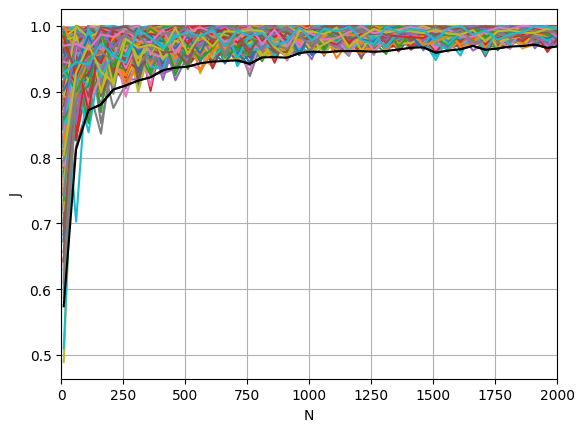

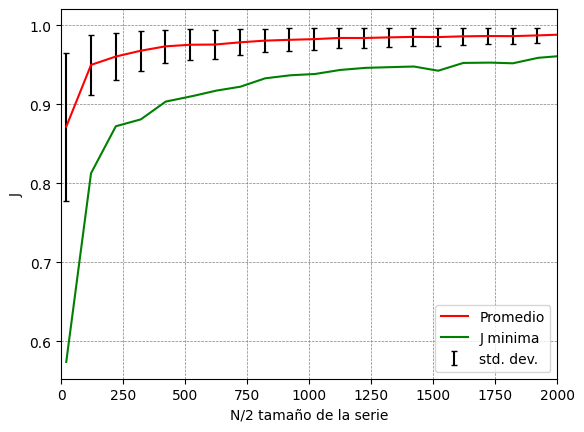

In [3]:
import matplotlib.pyplot as plt
from functools import partial
import numpy as np
import pickle

Ns = np.load('Ns.npy')
Js = np.load('J_composers.npy')
Jotas2 = np.load('Random/Jotas2.npy')
Jotas3 = np.load('Random/Jotas3.npy') #Jotas.npy contiene los 100 vectores de J hipotesis nula
Jotas4 = np.load('Random/Jotas4.npy')
Jotas5 = np.load('Random/Jotas5.npy')
Jotas6 = np.load('Random/Jotas6.npy')
Jotas7 = np.load('Random/Jotas7.npy')
# Jotas = np.zeros((100,len(range(20,14000,100))))
# print(np.shape(Jotas), len(range(20,14000,100)))
randoms = np.random.uniform(0, 1, (100, 14000))
# print(np.shape(np.mean([Jotas2,Jotas],axis=0)))
stack = np.vstack((Jotas2,Jotas3,Jotas4,Jotas5,Jotas6,Jotas7))
Jotas = np.mean([Jotas2,Jotas3,Jotas4,Jotas5,Jotas6,Jotas7],axis=0)
# for n,i in enumerate(range(20, 14000, 100)):
    # J_univariante_parcial = partial(J_univariante,tau=1,corte=False, j = i)
    # J_por_i = np.apply_along_axis(J_univariante_parcial, axis =1 , arr=randoms[:,:i])
    # Jotas[:,n] = J_por_i
    # print(i)
# # print(J_univariante(np.random.uniform(0.0,1.0, 5000), 1, False))
# np.save('Random/Jotas7.npy', Jotas)
x = np.arange(20, 14000, 100)
xx = np.arange(20, 13921, 1)
J_mean = np.mean(stack, axis=0)
J_std = np.std(stack, axis = 0)
J_minus = np.mean([np.min(Jotas2,axis=0),np.min(Jotas3,axis=0),np.min(Jotas4,axis=0),
 np.min(Jotas5,axis=0),np.min(Jotas6,axis=0),np.min(Jotas7,axis=0)], axis=0)
# J_minus = np.min(Jotas, axis=0)
# print(J_minus_intr[1,2000-20])
J_minus = interpolador(J_minus, 'lineal', 99)
J_minus_intr = np.zeros((2, 13901))
J_minus_intr[1,:] = J_minus[1]
J_minus_intr[0,:] = xx
np.save('J_minus_continuo.npy', J_minus_intr)
for i in range(100*6):
    plt.plot(x//2, stack[i,:])
plt.plot(xx//2, J_minus[1], 'black')
plt.xlabel('N')
plt.ylabel('J')
plt.xlim(0,2000)
plt.grid()
plt.show()
fig, ax = plt.subplots()
ax.errorbar(x = x[::], y = J_mean[::], yerr= J_std[::], fmt='none', ecolor = 'black', capsize=2,label='std. dev.')
ax.plot(x, J_mean, color = 'red', label = 'Promedio')

# ax.set_ylim(0.7, 1)
ax.set_xlabel('N/2 tamaño de la serie')
ax.set_ylabel('J') 
# plt.scatter(len(canon), canon_j, marker ='.', color = 'green')
ax.plot(xx, J_minus[1], 'green', label='J minima')
ax.legend()
ax.set_xlim(0,2000)
plt.grid(True, which='both', linestyle='--', color='gray', linewidth=0.5)
plt.show()

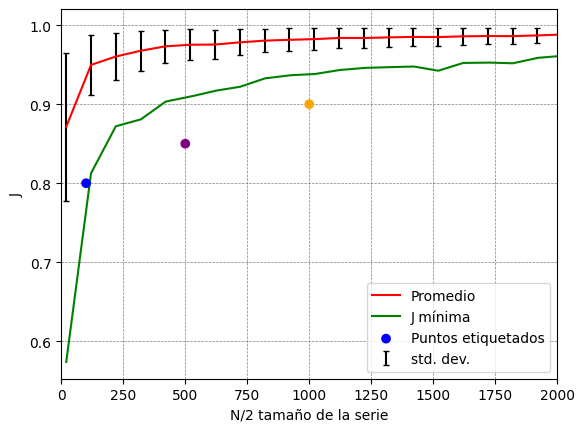

In [5]:
import matplotlib.pyplot as plt
import mplcursors

# Tu código de datos aquí
# Graficar barras de error
plt.errorbar(x=x, y=J_mean, yerr=J_std, fmt='none', ecolor='black', capsize=2, label='std. dev.')

# Graficar curva promedio
plt.plot(x, J_mean, color='red', label='Promedio')

# Graficar curva J mínima
plt.plot(xx, J_minus[1], 'green', label='J mínima')

# Definir puntos personalizados con color y label
puntos_x = [100, 500, 1000]  # Ejemplo de coordenadas x
puntos_y = [0.8, 0.85, 0.9]  # Ejemplo de coordenadas y
puntos_labels = ['A', 'B', 'C']
puntos_colors = ['blue', 'purple', 'orange']

# Agregar los puntos a la gráfica
sc = plt.scatter(puntos_x, puntos_y, c=puntos_colors, label='Puntos etiquetados', zorder=3)

# Crear cursores interactivos con labels
cursor = mplcursors.cursor(sc, hover=True)
cursor.connect("add", lambda sel: sel.annotation.set_text(puntos_labels[sel.index]))

# Configurar ejes y leyenda
plt.xlabel('N/2 tamaño de la serie')
plt.ylabel('J')
plt.xlim(0, 2000)
plt.legend()
plt.grid(True, which='both', linestyle='--', color='gray', linewidth=0.5)

# Mostrar la gráfica
plt.show()


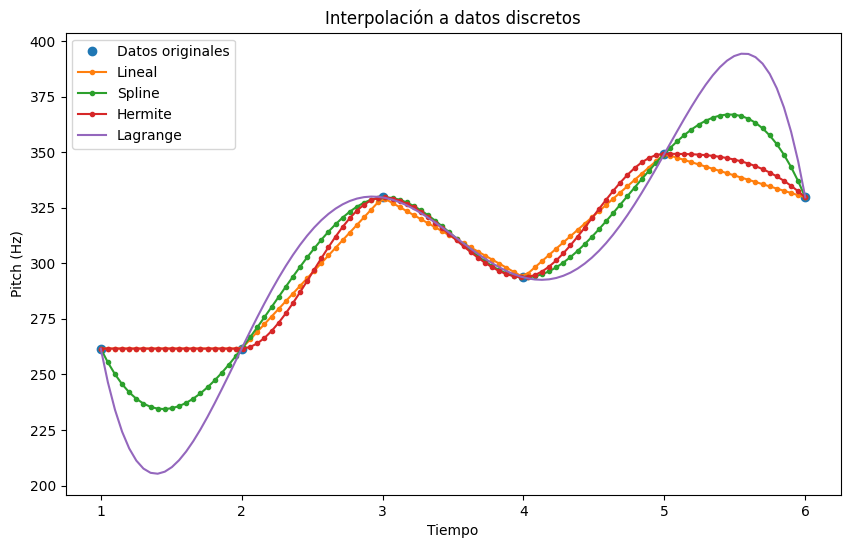

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
from numpy.polynomial import Polynomial
from scipy.interpolate import lagrange
from scipy.interpolate import PchipInterpolator
from pykrige.ok import OrdinaryKriging


times = np.array([1, 2, 3, 4, 5, 6])
pitches = np.array([261.63, 261.63, 329.63, 293.66, 349.23, 329.63]) 

# Interpolacion Lineal
linear_interp = interp1d(times, pitches, kind='linear')

# Interpolacion Spline
spline_interp = CubicSpline(times, pitches)

# Interpolacion de Lagrange
lagrange_interp = lagrange(times, pitches)

#Interpolacion de Hermite
hermite_interp = PchipInterpolator(times, pitches)


# Generar puntos para graficar
fine_times = np.linspace(1, 6, 100)
linear_pitches = linear_interp(fine_times)
spline_pitches = spline_interp(fine_times)
lagrange_pitches = lagrange_interp(fine_times)
hermite_pitches = hermite_interp(fine_times)


# Graficar
plt.figure(figsize=(10, 6))
plt.plot(times, pitches, 'o', label='Datos originales')
plt.plot(fine_times, linear_pitches, '.-', label='Lineal')
plt.plot(fine_times, spline_pitches, '.-', label='Spline')
plt.plot(fine_times, hermite_pitches, '.-', label='Hermite')
plt.plot(fine_times, lagrange_pitches, label='Lagrange')
plt.xlabel('Tiempo')
plt.ylabel('Pitch (Hz)')
plt.legend()
plt.title('Interpolación a datos discretos')
plt.show()
